In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
bank = pd.read_excel(r'..\raw_data\2025_World_Bank_classification.xlsx', 'List of economies', header=2)
bank

,Country,Code,Region,Income group,Classification
0,Afghanistan,AFG,South Asia,Low income,LIC
1,Albania,ALB,Europe & Central Asia,Upper middle income,UMIC
2,Algeria,DZA,Middle East & North Africa,Upper middle income,UMIC
3,American Samoa,ASM,East Asia & Pacific,High income,HIC
4,Andorra,AND,Europe & Central Asia,High income,HIC
...,...,...,...,...,...
213,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,HIC
214,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income,LMIC
215,"Yemen, Rep.",YEM,Middle East & North Africa,Low income,LIC
216,Zambia,ZMB,Sub-Saharan Africa,Lower middle income,LMIC


In [3]:
test = pd.read_csv(r'..\co2_calc\emissions_v3\total_all.csv')
test

,Country,year,emissions
0,AFG,1990,1875.263718
1,AFG,1995,1601.205643
2,AFG,2000,1535.029465
3,AFG,2005,1423.286605
4,AFG,2010,1380.266919
...,...,...,...
170,SDN,2020,291.889527
171,SYR,2020,639.409673
172,TUN,2020,659.250688
173,YEM,2020,367.089431


In [4]:
for i in test['Country'].unique():
    if i not in bank['Code'].values:
        print(i)

EMR


In [5]:
test['income_group'] = test['Country'].map(bank.set_index('Code')['Income group'])
test

,Country,year,emissions,income_group
0,AFG,1990,1875.263718,Low income
1,AFG,1995,1601.205643,Low income
2,AFG,2000,1535.029465,Low income
3,AFG,2005,1423.286605,Low income
4,AFG,2010,1380.266919,Low income
...,...,...,...,...
170,SDN,2020,291.889527,Low income
171,SYR,2020,639.409673,Low income
172,TUN,2020,659.250688,Lower middle income
173,YEM,2020,367.089431,Low income


In [6]:
test['income_group'].value_counts()/8

income_group
Lower middle income    8.000
High income            6.000
Low income             5.000
Upper middle income    1.875
Name: count, dtype: float64

In [7]:
def grouper(df_path, name=None):
    test = pd.read_csv(df_path)
    try:
        test['income_group'] = test['Country'].map(bank.set_index('Code')['Income group'])
    except:
        test['income_group'] = test['iso3'].map(bank.set_index('Code')['Income group'])

    if name:
        test.to_csv(name, index=False)
    return test

In [8]:
t2 = grouper(r'..\diet_calc\scores\phdi\total_all.csv')
t2

,Country,1990,1995,2000,2005,2010,2015,2018,2020,income_group
0,AFG,73.0,71.5,68.0,68.0,72.0,71.0,74.0,NaN,Low income
1,ARE,56.5,52.0,53.5,67.0,75.5,76.0,72.0,NaN,High income
2,BHR,67.5,69.5,68.5,67.5,72.5,72.5,73.5,NaN,High income
3,DJI,60.0,67.0,73.5,75.0,63.0,74.0,69.0,NaN,Lower middle income
4,EGY,66.5,67.5,70.0,67.0,66.0,64.0,66.0,NaN,Lower middle income
5,IRN,65.5,64.5,67.5,68.5,71.5,71.5,74.5,NaN,Upper middle income
6,IRQ,69.0,82.0,66.5,67.0,68.0,58.0,65.5,NaN,Upper middle income
7,JOR,63.0,65.0,64.0,60.0,61.0,64.0,64.0,NaN,Lower middle income
8,KWT,64.0,56.5,56.0,63.5,61.5,60.0,61.0,NaN,High income
9,LBN,75.0,78.0,79.5,74.0,78.0,86.0,88.0,NaN,Lower middle income


In [9]:
t2.groupby('income_group').mean(numeric_only=True).round(2)

,1990,1995,2000,2005,2010,2015,2018,2020
income_group,,,,,,,,
High income,66.00,64.42,64.83,67.08,70.92,71.25,71.42,NaN
Low income,68.40,71.40,70.80,69.60,69.60,69.90,69.10,NaN
Lower middle income,64.25,65.62,66.69,66.25,65.56,68.12,68.50,NaN
Upper middle income,67.25,73.25,67.00,67.75,69.75,64.75,70.00,NaN


In [10]:
import os

pre = [
    (r'D:\Prog\ICRI\climate_change\co2_calc\emissions_v3\total_all.csv', 'emissions'),
    (r'..\diet_calc\scores\dash_dixon\total_all.csv', 'dash'),  # <--- Added missing comma
    (r'D:\Prog\ICRI\climate_change\diet_calc\scores\phdi\total_all.csv', 'phdi'),
    (r'D:\Prog\ICRI\climate_change\diet_calc\scores\medit_new\total_all.csv', 'medit')
]

# Create the folder safely (won't crash if it already exists)
os.makedirs('processed', exist_ok=True)

for i, j in pre:
    # Construct filename correctly: processed/emissions.csv
    outpath = os.path.join('processed', f'{j}.csv')
    grouper(i, outpath)

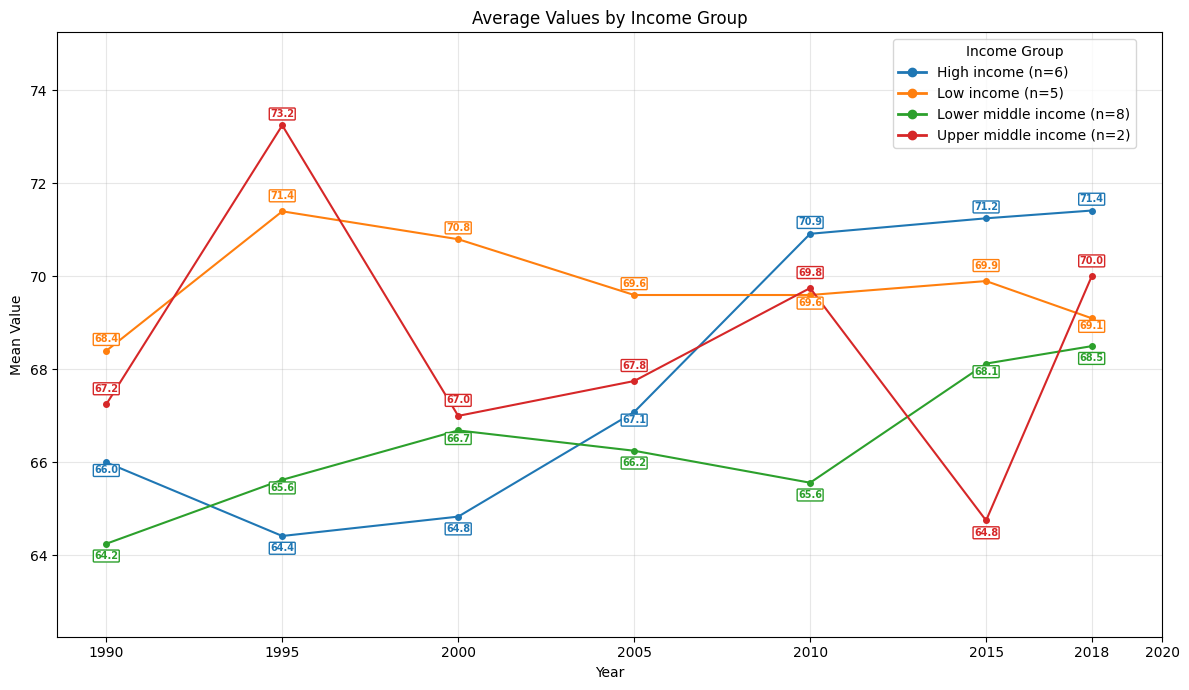

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import List, Dict

# ---------------------------------------------------------
# 1. Helper Function: Tight Annotations
# ---------------------------------------------------------
def _annotate_tight(
    ax: plt.Axes,
    entries: List[Dict],
    offset_up: int = 6,    # Very close to the dot (pixels)
    offset_down: int = -8  # Very close (slightly more to clear text height)
):
    groups: Dict[int, List[Dict]] = {}
    for e in entries:
        groups.setdefault(int(e["year"]), []).append(e)

    for year, items in groups.items():
        # Sort values so we know which is "top" and which is "bottom"
        items_sorted = sorted(items, key=lambda x: x["value"], reverse=True)
        
        # Simple split: Top half labels go UP, bottom half labels go DOWN
        mid = (len(items_sorted) + 1) // 2
        above_items = items_sorted[:mid]
        below_items = items_sorted[mid:]

        # Annotate Top items (slightly above line)
        for i, it in enumerate(above_items):
            # We add a tiny extra nudge (i*3) only if multiple points are stacked 
            # to prevent the boxes from overlapping each other perfectly
            nudge = offset_up + (i * 3) 
            
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, nudge),
                ha="center",
                fontsize=7,  # Small font to keep it tight
                fontweight='bold',
                color=it["color"],
                # Small padding (0.1) to reduce white box size
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=1.0),
                zorder=10
            )

        # Annotate Bottom items (slightly below line)
        for i, it in enumerate(below_items):
            nudge = offset_down - (i * 3)
            
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, nudge),
                ha="center",
                fontsize=7,
                fontweight='bold',
                color=it["color"],
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=1.0),
                zorder=10
            )

# ---------------------------------------------------------
# 2. Plotting
# ---------------------------------------------------------

# Prepare data
means = t2.groupby('income_group').mean(numeric_only=True).T
years = means.index.astype(int)
group_names = means.columns
counts = t2['income_group'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
color_map = {name: col for name, col in zip(group_names, colors)}

entries_for_annotation = []
legend_handles = []

for name in group_names:
    color = color_map[name]
    y_mean = means[name]
    n_count = counts.get(name, 0)
    label_str = f"{name} (n={n_count})"
    
    # Plot Line
    ax.plot(
        years, y_mean, 
        marker='o', markersize=4, # Smaller marker
        color=color, linewidth=1.5, 
        label=label_str
    )
    
    # Collect data
    for yr, val in zip(years, y_mean):
        entries_for_annotation.append({
            "year": yr,
            "value": val,
            "text": f"{val:.1f}", 
            "color": color
        })
        
    legend_handles.append(Line2D([0], [0], color=color, marker='o', lw=2, label=label_str))

# ---------------------------------------------------------
# 3. Apply Styling
# ---------------------------------------------------------

_annotate_tight(ax, entries_for_annotation)

ax.set_title('Average Values by Income Group')
ax.set_ylabel('Mean Value')
ax.set_xlabel('Year')
ax.set_xticks(years)


# Auto-scale Y with small margin
y_min, y_max = means.min().min(), means.max().max()
ax.set_ylim(y_min - 2, y_max + 2) 

ax.grid(alpha=0.3)
ax.legend(handles=legend_handles, title='Income Group', bbox_to_anchor=(0.75, 1), loc='upper left')
plt.set_cmap('Blues')
plt.tight_layout()
plt.show()

In [12]:


df_co2 = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\emissions.csv').dropna(subset=['income_group'])
df_dash = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\dash.csv').dropna(subset=['income_group'])
df_phdi = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\phdi.csv').dropna(subset=['income_group'])
df_medit = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\medit.csv').dropna(subset=['income_group'])